In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import pydpeet as eet

NOTEBOOK_DIR = Path.cwd()
RES_DIR = NOTEBOOK_DIR.parent.parent / "res" / "Tutorial_02"

eet.set_logging_style("ERROR")

In [3]:
# df_standardized = pd.DataFrame(eet.read(
#     config = eet.ReadConfig.Neware_8_0_0_516,
#     input_path = str(RES_DIR / "Cal_Ageing_Checkup1.xlsx")
# ))

df_standardized = pd.read_parquet(str(RES_DIR / "standardized_df.parquet"))

In [4]:
segmented_df = eet.add_primitive_segments(df=df_standardized, config=eet.PrimitiveConfig.OCV_ANALYSIS_DEFAULT)
segmented_df

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0,20240222172614-CheckUp-3-8-AM23NMC00009.xlsx U...,0,3.5409,1.4379,29.3,0.0,2024-02-22 17:26:15,None,None,None,...,1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up,0.000074
1,None,0,3.5424,1.4395,29.3,1.0,2024-02-22 17:26:16,None,None,None,...,1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up,0.000074
2,None,0,3.5434,1.4397,29.1,2.0,2024-02-22 17:26:17,None,None,None,...,1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up,0.000074
3,None,0,3.5444,1.4398,29.1,3.0,2024-02-22 17:26:18,None,None,None,...,1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up,0.000074
4,None,0,3.5451,1.4399,29.1,4.0,2024-02-22 17:26:19,None,None,None,...,1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up,0.000074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167006,None,491,4.1887,0.0000,25.5,166345.9,2024-02-24 15:39:47,None,None,None,...,495,I,3600.0,3599.0,0.0000,0.0000,0.000000,Rest,Neutral,0.000000
167007,None,491,4.1887,0.0000,25.5,166346.9,2024-02-24 15:39:48,None,None,None,...,495,I,3600.0,3599.0,0.0000,0.0000,0.000000,Rest,Neutral,0.000000
167008,None,491,4.1887,0.0000,25.5,166347.9,2024-02-24 15:39:49,None,None,None,...,495,I,3600.0,3599.0,0.0000,0.0000,0.000000,Rest,Neutral,0.000000
167009,None,491,4.1886,0.0000,25.5,166348.9,2024-02-24 15:39:50,None,None,None,...,495,I,3600.0,3599.0,0.0000,0.0000,0.000000,Rest,Neutral,0.000000


In [5]:
segmented_df.groupby("ID")[["Variable", "Duration", "Length", "Min", "Max", "Avg", "Type", "Direction"]].first()

,Variable,Duration,Length,Min,Max,Avg,Type,Direction
ID,,,,,,,,
1,V,8883.0,8882.0,3.5409,4.2001,3.895954,Ramp,Up
2,V,2368.0,2366.6,4.2002,4.2004,4.200279,Constant,Charge
3,I,60.0,59.0,0.0000,0.0000,0.000000,Rest,Neutral
4,I,17783.0,17782.0,-0.9601,-0.9599,-0.960000,Constant,Discharge
5,V,433.0,431.5,2.5001,2.5023,2.500127,Constant,Discharge
...,...,...,...,...,...,...,...,...
491,I,98.0,96.1,1.4394,1.4398,1.439642,Constant,Charge
492,I,360.0,359.0,0.0000,0.0000,0.000000,Rest,Neutral
493,I,88.0,86.7,1.4391,1.4399,1.439655,Constant,Charge


In [6]:
# Calculate custom thresholds based on a device config
thresholds = eet.DeviceConfig.NEWARE_CT_4008Q_5V12A_S1
voltage_diff, current_diff = eet.calculate_minimum_definitive_differences(*thresholds)

segmented_df_custom = eet.add_primitive_segments(
    df=df_standardized,
    config=eet.primitive_config_wrapper(
        threshold_dict=thresholds,
        # nonsensical example values to showcase different methods of setting the config
        segments_to_detect_config=[
            ("Voltage[V]", voltage_diff),
            ("Current[A]", current_diff / 2),
            ("Power[W]", 0.5),
        ],
        supress_io_warnings=True,
    ),
)

segmented_df_custom.groupby("ID")[["Variable", "Duration", "Length", "Min", "Max", "Avg", "Type", "Direction"]].first()

,Variable,Duration,Length,Min,Max,Avg,Type,Direction
ID,,,,,,,,
0,P,8809.0,8808.0,5.091460,6.037864,5.605868,Ramp,Up
1,V,2502.0,2500.6,4.195300,4.200400,4.200151,Ramp,Up
2,I,17783.0,17782.0,-0.960100,-0.959900,-0.960000,Constant,Discharge
3,P,3.0,2.0,-2.365174,-2.207206,-2.279883,Ramp,Up
4,V,430.0,428.5,2.500100,2.500500,2.500117,Constant,Discharge
...,...,...,...,...,...,...,...,...
488,I,360.0,359.0,0.000000,0.000000,0.000000,Rest,Neutral
489,V,98.0,96.1,4.161000,4.192100,4.179936,Ramp,Up
490,I,360.0,359.0,0.000000,0.000000,0.000000,Rest,Neutral


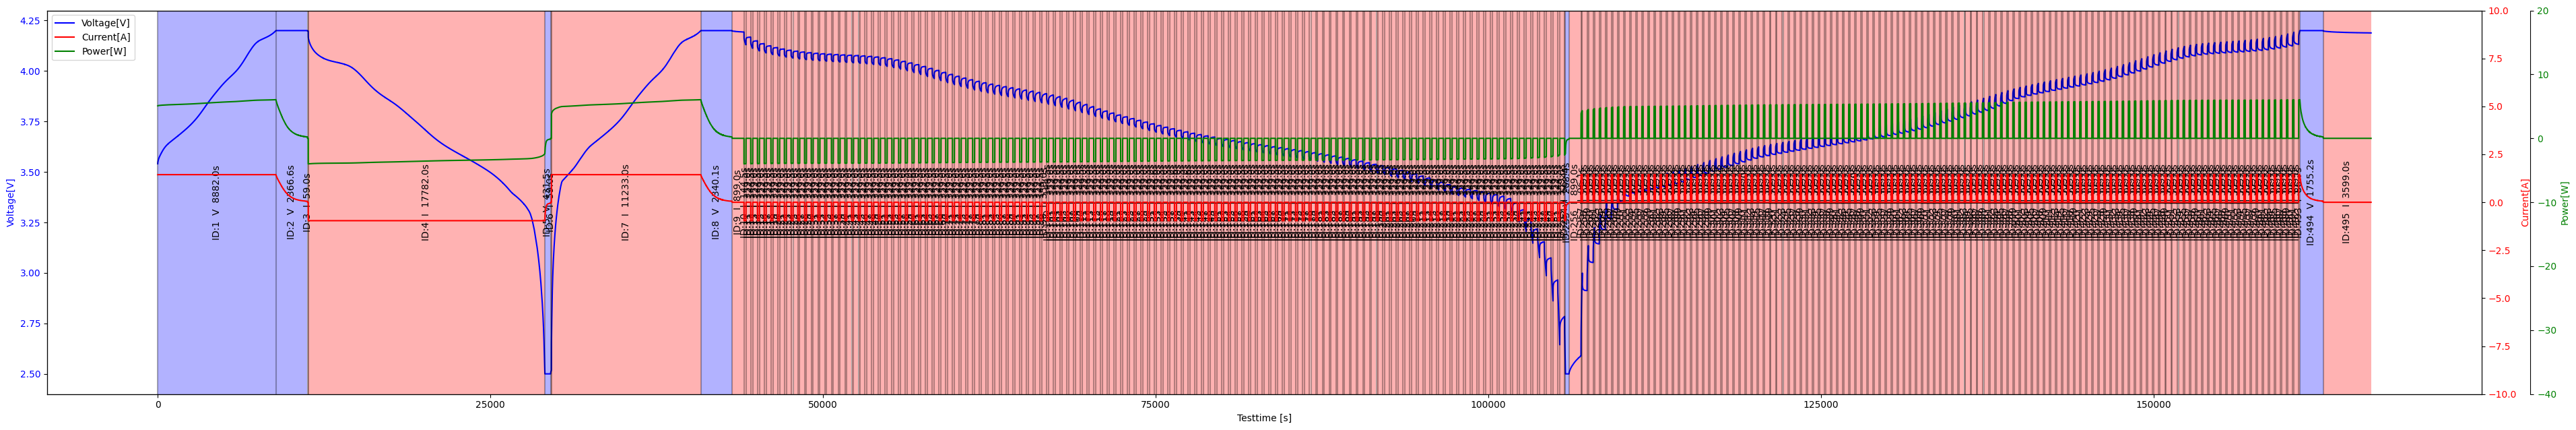

In [7]:
eet.visualize_phases(dataframe=segmented_df, config=eet.VisualizationConfig.DEFAULT)
plt.show()

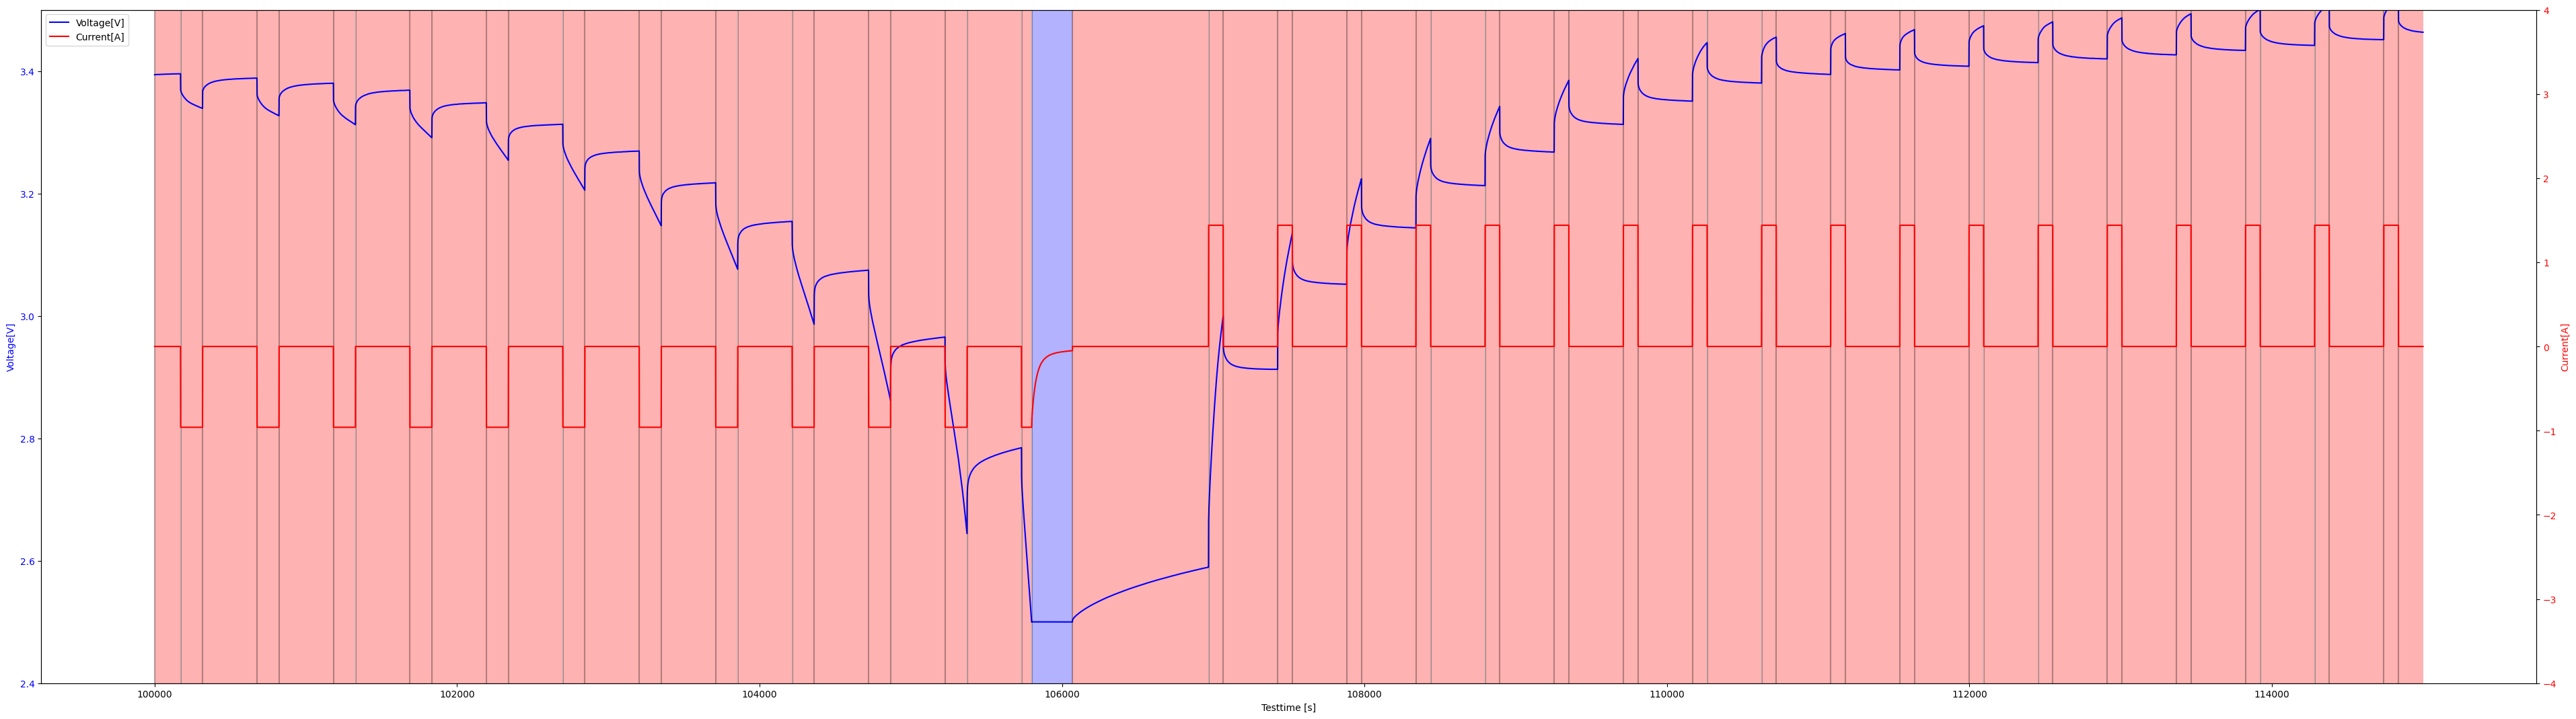

In [11]:
eet.visualize_phases(
    dataframe=segmented_df,
    config=eet.visualization_config_wrapper(  # overwritten the default values
        start=100000,
        end=115000,
        width_height_ratio=[1, 0.5],
        visualize_phases_config=[
            ("V", "blue"),
            ("I", "red"),
        ],
        line_visualization_config=[
            ("Voltage[V]", "blue", (2.4, 3.5)),
            ("Current[A]", "red", (-4, 4)),
        ],
        show_id=False,
        show_time=False,
        show_column_names=False,
    ),
)
plt.show()